In [9]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMG_SIZE=64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])
aug_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])


def get_dataloaders(data_dir, batch_size=24, shuffle=True, transform=val_transform):
    """Larger batch size now that we have memory"""
    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    
    # 1. Get a batch of real data
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)
    
    # 2. Pick only the cats (Label 0) from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: 
        print("No cats found in this batch to transform.")
        return
    
    # Take top 4 cats
    cats = images[cat_indices[:4]]
    n_samples = len(cats)
    
    # Create the labels we need
    cat_labels = torch.zeros(n_samples, dtype=torch.long).to(device)
    dog_labels = torch.ones(n_samples, dtype=torch.long).to(device) # Target Label
    
    with torch.no_grad():
        # --- STEP A: Pixel -> Latent (Frozen VAE) ---
        # We must compress the real cat images so your model can read them
        posterior = model.pretrained_vae.encode(cats).latent_dist
        cat_latents = posterior.sample() * 0.18215
        
        # --- STEP B: Encode (Your Model) ---
        # Your model takes the compressed cat + cat label -> finds the "content vector" (mu)
        mu, _ = model.encode(cat_latents, cat_labels)
        
        # --- STEP C: Decode (Your Model) ---
        # We assume the content is the same, but we swap the label to "Dog"
        # Your model predicts what the DOG Latents should look like
        transformed_latents = model.decode(mu, dog_labels)
        
        # --- STEP D: Latent -> Pixel (Frozen VAE) ---
        # Unscale and decode to see the final image
        transformed_latents = transformed_latents / 0.18215
        transformed_dogs = model.pretrained_vae.decode(transformed_latents).sample

    # --- Plotting ---
    # Move to CPU for plotting
    cats = cats.cpu()
    transformed_dogs = transformed_dogs.cpu()
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    
    # Handle cases where we found fewer than 4 cats
    for i in range(4):
        if i < n_samples:
            # 1. Show Original Cat
            # Denormalize: [-1, 1] -> [0, 1]
            orig_img = (cats[i].permute(1, 2, 0) + 1) / 2
            axes[0, i].imshow(orig_img.clamp(0, 1))
            axes[0, i].set_title("Original Cat")
            axes[0, i].axis('off')
            
            # 2. Show Transformed Dog
            # Denormalize: [-1, 1] -> [0, 1]
            trans_img = (transformed_dogs[i].permute(1, 2, 0) + 1) / 2
            axes[1, i].imshow(trans_img.clamp(0, 1))
            axes[1, i].set_title("Transformed Dog")
            axes[1, i].axis('off')
        else:
            # Hide empty axes if we found fewer than 4 cats
            axes[0, i].axis('off')
            axes[1, i].axis('off')
            
    plt.tight_layout()
    plt.show()


Using device: cuda


In [10]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

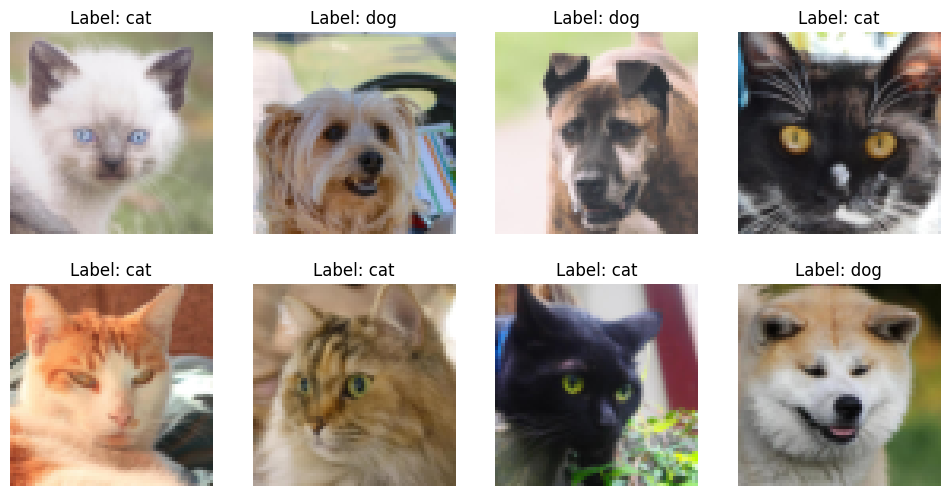

In [11]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")
show_batch(train_loader, train_classes)

## Architecture Improvements

**Inspired from `stuff.txt`, the new architecture features:**

1. **Sinusoidal Time Embedding** - Proper positional encoding (like Transformers) instead of simple linear mapping
   - Better captures temporal information across timesteps
   - Smoother gradient flow during backprop

2. **ResBlock-based Design** - Clean residual blocks with explicit conditioning
   - Each ResBlock takes time + CLIP embeddings as inputs
   - Time and CLIP modulations are additive (FiLM-like) - simpler and faster than AdaIN
   - Proper skip connections prevent vanishing gradients

3. **Cleaner Conditioning** - Separate MLPs for time and CLIP embeddings
   - Time MLP projects sinusoidal embedding to latent space
   - CLIP MLP projects 512-dim CLIP embedding to same latent space
   - Both added to features for modulation

4. **Lightweight Architecture** - Still compact for fast training
   - Channels: 32 → 64 → 128 (vs 32 → 64 → 128)
   - Uses ModuleList for efficient parameter management
   - SiLU activation (faster than GELU) with GroupNorm

5. **Benefits:**
   - ✅ Better quality conditional generation (cat→dog)
   - ✅ Faster training (simpler conditioning, SiLU activation)
   - ✅ Better generative quality (sinusoidal time embedding)
   - ✅ Smaller model size than original AdaIN version


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding - inspired by Transformer positional encoding"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        """t: [B] timesteps"""
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * -emb)
        emb = t.float()[:, None] * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=1)

class ResBlock(nn.Module):
    """Residual block with time and CLIP conditioning - cleaner and faster than AdaIN"""
    def __init__(self, in_ch, out_ch, time_dim, cond_dim):
        super().__init__()
        
        # Time conditioning MLP
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, out_ch),
            nn.SiLU(),
        )
        
        # CLIP conditioning MLP
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, out_ch),
            nn.SiLU(),
        )
        
        # Main convolution path
        self.norm1 = nn.GroupNorm(min(8, max(1, in_ch // 4)), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        
        self.norm2 = nn.GroupNorm(min(8, max(1, out_ch // 4)), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        
        self.act = nn.SiLU()
        
        # Residual skip
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    
    def forward(self, x, t_emb, cond_emb):
        """
        Args:
            x: [B, C, H, W]
            t_emb: [B, time_dim]
            cond_emb: [B, cond_dim]
        """
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        
        # Add time and condition modulation
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = h + self.cond_mlp(cond_emb)[:, :, None, None]
        
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        
        return h + self.skip(x)

class ConditionalUNet(nn.Module):
    """Lightweight conditional U-Net with ResBlocks - fast training, good quality"""
    def __init__(self, c_in=3, c_out=3, channels=(32, 64, 128), time_dim=128, cond_dim=512, device="cuda"):
        super().__init__()
        self.device = device
        self.time_dim = time_dim
        self.cond_dim = cond_dim
        self.channels = channels
        
        # 1. Sinusoidal time embedding
        self.time_embed = TimeEmbedding(time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        
        # 2. CLIP embedding projection
        self.cond_proj = nn.Sequential(
            nn.Linear(cond_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        
        # 3. Initial convolution
        self.inc = nn.Conv2d(c_in, channels[0], 3, padding=1)
        
        # 4. Downsampling - each level: MaxPool + ResBlock
        self.down_blocks = nn.ModuleList([
            ResBlock(channels[0], channels[1], time_dim, time_dim),
            ResBlock(channels[1], channels[2], time_dim, time_dim),
            ResBlock(channels[2], channels[2], time_dim, time_dim),
        ])
        
        # 5. Middle ResBlock
        self.mid = ResBlock(channels[2], channels[2], time_dim, time_dim)
        
        # 6. Upsampling - each level: Upsample + ResBlock
        self.up_blocks = nn.ModuleList([
            ResBlock(channels[2] + channels[2], channels[1], time_dim, time_dim),
            ResBlock(channels[1] + channels[1], channels[0], time_dim, time_dim),
            ResBlock(channels[0] + channels[0], channels[0], time_dim, time_dim),
        ])
        
        # 7. Output
        self.norm_out = nn.GroupNorm(8, channels[0])
        self.act_out = nn.SiLU()
        self.outc = nn.Conv2d(channels[0], c_out, 1)
    
    def forward(self, x, t, clip_emb):
        """
        Args:
            x: [B, 3, H, W] noisy images
            t: [B] timesteps
            clip_emb: [B, 512] CLIP embeddings
        """
        # Embeddings
        t_emb = self.time_embed(t)  # [B, time_dim]
        t_emb = self.time_mlp(t_emb)  # [B, time_dim]
        
        cond_emb = self.cond_proj(clip_emb)  # [B, time_dim]
        
        # Downsampling with skip connections
        x0 = self.inc(x)
        
        # Down 1
        x1 = F.max_pool2d(x0, 2)
        x1 = self.down_blocks[0](x1, t_emb, cond_emb)
        
        # Down 2
        x2 = F.max_pool2d(x1, 2)
        x2 = self.down_blocks[1](x2, t_emb, cond_emb)
        
        # Down 3
        x3 = F.max_pool2d(x2, 2)
        x3 = self.down_blocks[2](x3, t_emb, cond_emb)
        
        # Middle
        x = self.mid(x3, t_emb, cond_emb)
        
        # Upsampling with skip connections
        # Up 1: 8x8 -> 16x16, concat with x2
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, x2], dim=1)
        x = self.up_blocks[0](x, t_emb, cond_emb)
        
        # Up 2: 16x16 -> 32x32, concat with x1
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, x1], dim=1)
        x = self.up_blocks[1](x, t_emb, cond_emb)
        
        # Up 3: 32x32 -> 64x64, concat with x0
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, x0], dim=1)
        x = self.up_blocks[2](x, t_emb, cond_emb)
        
        # Output
        x = self.norm_out(x)
        x = self.act_out(x)
        x = self.outc(x)
        
        return x

class Diffusion:
    def __init__(self, noise_steps=1000, img_size=64, device="cuda", schedule="cosine"):
        self.noise_steps = noise_steps
        self.img_size = img_size
        self.device = device
        
        if schedule == "cosine":
            self.beta = self.cosine_beta_schedule(noise_steps).to(device)
        else:
            self.beta = torch.linspace(1e-4, 0.02, noise_steps).to(device)
        
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def cosine_beta_schedule(self, timesteps, s=0.008):
        """Cosine schedule"""
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,)).to(self.device)

    def img2img(self, model, image, target_label, clip_embeddings, start_step=500):
        """Translate image with CLIP conditioning"""
        model.eval()
        n = image.shape[0]
        
        t_start = torch.full((n,), start_step, device=self.device, dtype=torch.long)
        x, _ = self.noise_images(image, t_start)
        
        target_clip_emb = clip_embeddings[target_label].unsqueeze(0).expand(n, -1)
        
        with torch.no_grad():
            for i in reversed(range(1, start_step)):
                t = torch.ones(n) * i
                t = t.long().to(self.device)
                
                predicted_noise = model(x, t, target_clip_emb)
                
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                
                x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        
        return (x.clamp(-1, 1) + 1) / 2


In [13]:
# Load CLIP text encoder
from transformers import CLIPTextModel, CLIPTokenizer

print("Loading CLIP text encoder...")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_encoder.eval()
for param in clip_encoder.parameters():
    param.requires_grad = False

# Pre-compute CLIP embeddings for cat and dog
with torch.no_grad():
    cat_tokens = tokenizer(["a cat"], padding=True, return_tensors="pt").to(device)
    cat_embed = clip_encoder(**cat_tokens).pooler_output  # (1, 512)
    
    dog_tokens = tokenizer(["a dog"], padding=True, return_tensors="pt").to(device)
    dog_embed = clip_encoder(**dog_tokens).pooler_output  # (1, 512)

clip_embeddings = {0: cat_embed.squeeze(0), 1: dog_embed.squeeze(0)}
print(f"CLIP embedding shape: {clip_embeddings[0].shape}")
print("✓ CLIP loaded and ready")

Loading CLIP text encoder...
CLIP embedding shape: torch.Size([512])
✓ CLIP loaded and ready


# Training util functions

In [14]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs, img_size=128, clip_embeddings=None):
    model.train()
    train_loss = 0
    
    # Instantiate the Diffusion helper
    diffusion = Diffusion(img_size=img_size, device=device, schedule="cosine")
    mse = nn.MSELoss()
    
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # --- Get CLIP embeddings for batch ---
        clip_cond = torch.stack([clip_embeddings[int(l)] for l in labels]).to(device)
        
        # --- Diffusion Training Steps ---
        t = diffusion.sample_timesteps(data.shape[0])
        x_t, noise = diffusion.noise_images(data, t)
        
        # Classifier-free guidance: 10% of the time, use null embedding (zeros)
        # This forces the model to generate good content without conditioning
        mask = torch.rand(data.shape[0], device=device) < 0.1
        null_emb = torch.zeros_like(clip_cond)
        clip_cond_masked = torch.where(mask.unsqueeze(1), null_emb, clip_cond)
        
        predicted_noise = model(x_t, t, clip_cond_masked)
        
        loss = mse(noise, predicted_noise)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader)
    return avg_loss

def validate_epoch(model, dataloader, device, img_size=128, clip_embeddings=None):
    model.eval()
    val_loss = 0
    
    diffusion = Diffusion(img_size=img_size, device=device, schedule="cosine")
    mse = nn.MSELoss()
    
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            # --- Get CLIP embeddings for batch ---
            clip_cond = torch.stack([clip_embeddings[int(l)] for l in labels]).to(device)
            
            t = diffusion.sample_timesteps(data.shape[0])
            x_t, noise = diffusion.noise_images(data, t)
            
            predicted_noise = model(x_t, t, clip_cond)
            
            loss = mse(noise, predicted_noise)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader)
    return avg_loss


# Training Loop

In [15]:
import os
from pathlib import Path
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt

def translate_species(model, diffusion, image, source_label, clip_embeddings, strength=0.6, guidance_scale=2.0):
    """
    Translates an image from one species to another (Cat <-> Dog).
    
    Args:
        model: The trained ConditionalUNet.
        diffusion: The Diffusion instance.
        image: A single image tensor of shape (3, 64, 64).
        source_label: The integer label of the input image (0 or 1).
        clip_embeddings: Dict with CLIP embeddings {0: cat_embed, 1: dog_embed}
        strength (float): How much to change the image (0.0 to 1.0).
        guidance_scale (float): Classifier-free guidance strength (1.0 = no guidance, 3.0 = strong)
    """
    model.eval()
    
    # 1. Setup Data
    x = image.unsqueeze(0).to(model.device) 
    
    # Get target CLIP embedding (toggle: cat->dog or dog->cat)
    target_label_int = 1 - source_label
    target_clip_emb = clip_embeddings[target_label_int].unsqueeze(0).to(model.device)
    
    # 2. Determine Noise Level (t)
    start_step = int(diffusion.noise_steps * strength)
    t_start = torch.full((1,), start_step, device=model.device, dtype=torch.long)
    
    # 3. Forward Process (add noise)
    noisy_image, _ = diffusion.noise_images(x, t_start)
    x_gen = noisy_image
    
    # 4. Reverse Process with classifier-free guidance
    with torch.no_grad():
        for i in reversed(range(1, start_step)):
            t = torch.ones(1).long().to(model.device) * i
            
            # Predict noise with conditioning
            predicted_noise_cond = model(x_gen, t, target_clip_emb)
            
            # Predict noise without conditioning (null embedding)
            null_emb = torch.zeros_like(target_clip_emb)
            predicted_noise_uncond = model(x_gen, t, null_emb)
            
            # Classifier-free guidance: combine predictions
            predicted_noise = predicted_noise_uncond + guidance_scale * (predicted_noise_cond - predicted_noise_uncond)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            noise = torch.randn_like(x_gen) if i > 1 else torch.zeros_like(x_gen)
            
            x_gen = (1 / torch.sqrt(alpha)) * (
                x_gen - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise
            ) + torch.sqrt(beta) * noise

    # 5. Return processed image
    return (x_gen.clamp(-1, 1) + 1) / 2
# Create output directory for training visualizations
output_dir = Path("./training_visualizations")
output_dir.mkdir(exist_ok=True)

def save_training_samples(model, diffusion, dataloader, clip_embeddings, device, epoch, save_dir="./training_visualizations"):
    """
    Generate and save sample translations during training.
    Shows: Original Cat → Translated Dog + Original Dog → Translated Cat
    """
    model.eval()
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    
    with torch.no_grad():
        # Get one batch from validation set
        images, labels = next(iter(dataloader))
        images, labels = images.to(device), labels.to(device)
        
        # Split into cats and dogs
        cat_mask = labels == 0
        dog_mask = labels == 1
        
        cat_indices = torch.where(cat_mask)[0]
        dog_indices = torch.where(dog_mask)[0]
        
        # Take up to 3 of each
        cat_indices = cat_indices[:3]
        dog_indices = dog_indices[:3]
        
        # Create figure with translations
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Epoch {epoch} - Cat↔Dog Translation', fontsize=16, fontweight='bold')
        
        # Row 1: Cats -> Dogs
        for idx, cat_idx in enumerate(cat_indices):
            cat_img = images[cat_idx:cat_idx+1]
            
            # Translate to dog
            translated_dog = translate_species(
                model, diffusion, 
                images[cat_idx], 
                source_label=0, 
                clip_embeddings=clip_embeddings,
                strength=0.7,
                guidance_scale=2.0
            ).squeeze(0)
            
            # Display
            ax = axes[0, idx]
            cat_display = (cat_img.squeeze(0).cpu().permute(1, 2, 0) + 1) / 2
            ax.imshow(cat_display.clamp(0, 1))
            ax.set_title(f'Cat → Dog #{idx+1}', fontsize=12, fontweight='bold')
            ax.axis('off')
        
        # Row 2: Dogs -> Cats (if we have dogs)
        for idx, dog_idx in enumerate(dog_indices):
            dog_img = images[dog_idx:dog_idx+1]
            
            # Translate to cat
            translated_cat = translate_species(
                model, diffusion,
                images[dog_idx],
                source_label=1,
                clip_embeddings=clip_embeddings,
                strength=0.7,
                guidance_scale=2.0
            ).squeeze(0)
            
            # Display
            ax = axes[1, idx]
            dog_display = (dog_img.squeeze(0).cpu().permute(1, 2, 0) + 1) / 2
            ax.imshow(dog_display.clamp(0, 1))
            ax.set_title(f'Dog → Cat #{idx+1}', fontsize=12, fontweight='bold')
            ax.axis('off')
        
        plt.tight_layout()
        
        # Save figure
        save_path = save_dir / f"epoch_{epoch:03d}.png"
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close()
        
        print(f"  📸 Saved visualization to {save_path}")

def save_generation_samples(model, diffusion, clip_embeddings, device, epoch, n_cats=4, n_dogs=4, save_dir="./training_visualizations"):
    """Generate images from scratch (no conditioning initially)"""
    model.eval()
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    
    with torch.no_grad():
        # Generate cats
        x_cats = torch.randn((n_cats, 3, diffusion.img_size, diffusion.img_size)).to(device)
        target_clip_emb = clip_embeddings[0].unsqueeze(0).expand(n_cats, -1).to(device)
        
        for i in reversed(range(1, diffusion.noise_steps)):
            t = torch.ones(n_cats).long().to(device) * i
            
            predicted_noise_cond = model(x_cats, t, target_clip_emb)
            null_emb = torch.zeros_like(target_clip_emb)
            predicted_noise_uncond = model(x_cats, t, null_emb)
            predicted_noise = predicted_noise_uncond + 1.0 * (predicted_noise_cond - predicted_noise_uncond)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            noise = torch.randn_like(x_cats)
            x_cats = (1 / torch.sqrt(alpha)) * (x_cats - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            x_cats = torch.clamp(x_cats, -1.0, 1.0)
        
        x_cats = (x_cats.clamp(-1, 1) + 1) / 2
        
        # Generate dogs
        x_dogs = torch.randn((n_dogs, 3, diffusion.img_size, diffusion.img_size)).to(device)
        target_clip_emb = clip_embeddings[1].unsqueeze(0).expand(n_dogs, -1).to(device)
        
        for i in reversed(range(1, diffusion.noise_steps)):
            t = torch.ones(n_dogs).long().to(device) * i
            
            predicted_noise_cond = model(x_dogs, t, target_clip_emb)
            null_emb = torch.zeros_like(target_clip_emb)
            predicted_noise_uncond = model(x_dogs, t, null_emb)
            predicted_noise = predicted_noise_uncond + 1.0 * (predicted_noise_cond - predicted_noise_uncond)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            noise = torch.randn_like(x_dogs)
            x_dogs = (1 / torch.sqrt(alpha)) * (x_dogs - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            x_dogs = torch.clamp(x_dogs, -1.0, 1.0)
        
        x_dogs = (x_dogs.clamp(-1, 1) + 1) / 2
        
        # Plot
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle(f'Epoch {epoch} - Generated Images (from scratch)', fontsize=16, fontweight='bold')
        
        for i in range(n_cats):
            axes[0, i].imshow(x_cats[i].cpu().permute(1, 2, 0))
            axes[0, i].set_title(f'Generated Cat #{i+1}', fontweight='bold')
            axes[0, i].axis('off')
        
        for i in range(n_dogs):
            axes[1, i].imshow(x_dogs[i].cpu().permute(1, 2, 0))
            axes[1, i].set_title(f'Generated Dog #{i+1}', fontweight='bold')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        
        save_path = save_dir / f"generation_epoch_{epoch:03d}.png"
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close()
        
        print(f"  🎨 Saved generation samples to {save_path}")


In [16]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train", batch_size=12, transform=aug_transform)
val_loader, val_classes = get_dataloaders("./afhq/val", batch_size=12, shuffle=False)

# --- Configuration ---
num_epochs = 800  # Train longer now
learning_rate = 1e-4
img_size = IMG_SIZE

# Initialize Model - now competent with selective attention
model = ConditionalUNet(device=device).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model Parameters: {total_params:,} | Trainable: {trainable_params:,}")
print(f"Architecture: ResBlock-based U-Net with sinusoidal time embedding + CLIP conditioning")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-7
)

best_val_loss = np.inf
patience = 500
patience_counter = 0

# --- Main Loop ---
for epoch in range(1, num_epochs + 1):
    # Training
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs, img_size=img_size, clip_embeddings=clip_embeddings)
    
    # Validation
    val_loss = validate_epoch(model, val_loader, device, img_size=img_size, clip_embeddings=clip_embeddings)
    
    if epoch % 10==0:
        print(f'Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
    
    scheduler.step()
    
    # Save visualizations every 10 epochs
    if epoch % 10 == 0:
        try:
            print(f"  📊 Generating training visualizations...")
            diffusion_viz = Diffusion(img_size=IMG_SIZE, device=device, schedule="cosine")
            save_training_samples(model, diffusion_viz, val_loader, clip_embeddings, device, epoch)
            save_generation_samples(model, diffusion_viz, clip_embeddings, device, epoch, n_cats=4, n_dogs=4)
        except Exception as e:
            print(f"  ⚠️ Visualization failed: {e}")
    
    # Early stopping + checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print(f"  ✓ Saved best model (val_loss: {val_loss:.6f})")
        state_dict = deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs")
            break


Model Parameters: 1,426,211 | Trainable: 1,426,211
Architecture: ResBlock-based U-Net with sinusoidal time embedding + CLIP conditioning
  ✓ Saved best model (val_loss: 0.088187)
  ✓ Saved best model (val_loss: 0.067286)
  ✓ Saved best model (val_loss: 0.061651)
  ✓ Saved best model (val_loss: 0.057870)
  ✓ Saved best model (val_loss: 0.055061)
  ✓ Saved best model (val_loss: 0.050990)
Epoch 10/800: Train Loss: 0.052846 | Val Loss: 0.052299
  📊 Generating training visualizations...
  📸 Saved visualization to training_visualizations/epoch_010.png
  🎨 Saved generation samples to training_visualizations/generation_epoch_010.png
  ✓ Saved best model (val_loss: 0.049349)
  ✓ Saved best model (val_loss: 0.048724)
Epoch 20/800: Train Loss: 0.049795 | Val Loss: 0.048325
  📊 Generating training visualizations...
  📸 Saved visualization to training_visualizations/epoch_020.png
  🎨 Saved generation samples to training_visualizations/generation_epoch_020.png
  ✓ Saved best model (val_loss: 0.04832

KeyboardInterrupt: 

In [17]:
from pathlib import Path
import matplotlib.image as mpimg

def browse_training_visualizations(save_dir="./training_visualizations", n_epochs=None):
    """
    Browse saved training visualizations in order.
    Shows both translation and generation samples side-by-side.
    """
    save_dir = Path(save_dir)
    
    if not save_dir.exists():
        print("❌ No visualizations found. Run training first!")
        return
    
    # Get all epoch image files
    translation_files = sorted(save_dir.glob("epoch_*.png"))
    generation_files = sorted(save_dir.glob("generation_epoch_*.png"))
    
    if not translation_files:
        print("❌ No visualization files found in", save_dir)
        return
    
    print(f"📂 Found {len(translation_files)} translation samples and {len(generation_files)} generation samples")
    print("\nVisualization Progress:")
    print("=" * 70)
    
    # Show every nth epoch or all
    if n_epochs is None:
        files_to_show = translation_files
    else:
        files_to_show = translation_files[::max(1, len(translation_files) // n_epochs)]
    
    for trans_file in files_to_show:
        gen_file = trans_file.parent / trans_file.name.replace("epoch_", "generation_epoch_")
        
        # Get epoch number
        epoch_num = int(trans_file.stem.split("_")[1])
        
        # Create figure with both samples
        fig = plt.figure(figsize=(18, 8))
        
        # Translation samples
        ax1 = plt.subplot(1, 2, 1)
        trans_img = mpimg.imread(trans_file)
        ax1.imshow(trans_img)
        ax1.set_title(f"Epoch {epoch_num}: Cat↔Dog Translation", fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Generation samples
        if gen_file.exists():
            ax2 = plt.subplot(1, 2, 2)
            gen_img = mpimg.imread(gen_file)
            ax2.imshow(gen_img)
            ax2.set_title(f"Epoch {epoch_num}: Generated from Scratch", fontsize=14, fontweight='bold')
            ax2.axis('off')
        
        plt.tight_layout()
        plt.show()
        print(f"✓ Epoch {epoch_num}")

# Quick example to check what files exist
viz_dir = Path("./training_visualizations")
if viz_dir.exists():
    files = list(viz_dir.glob("epoch_*.png"))
    if files:
        print(f"✓ Visualization folder exists with {len(files)} saved epochs")
        print("  Run: browse_training_visualizations() to view all progress")


✓ Visualization folder exists with 75 saved epochs
  Run: browse_training_visualizations() to view all progress


In [58]:
model.load_state_dict(state_dict)
torch.save(state_dict,"diffusion_weights.pth")

# Visualize trained model output

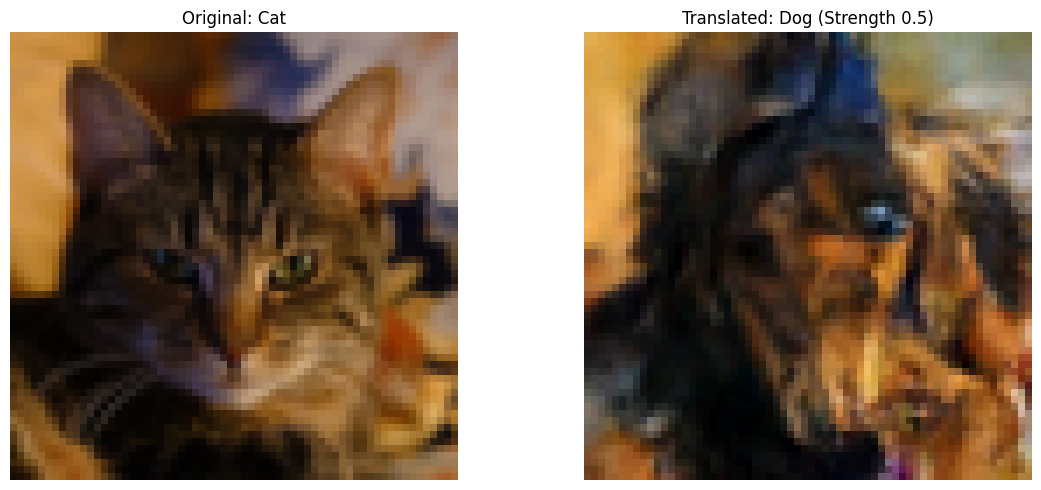

In [57]:
# --- Configuration ---
STRENGTH = 0.5 # Lower strength keeps more structure

# Get a real image from validation set
real_img, label = val_loader.dataset[1]

# Translate with CORRECT image size
diffusion_tools = Diffusion(img_size=IMG_SIZE, device=device, schedule="cosine")
model.load_state_dict(state_dict)
translated_img = translate_species(
    model, 
    diffusion_tools, 
    real_img, 
    label, 
    clip_embeddings,
    strength=STRENGTH,guidance_scale=4.0
)

# --- Visualization ---
real_img_show = (real_img.permute(1, 2, 0) + 1) / 2
trans_img_show = translated_img.squeeze().cpu().permute(1, 2, 0)

class_names = ['Cat', 'Dog']

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
plt.title(f"Original: {class_names[label]}")
plt.imshow(real_img_show.clamp(0, 1))
plt.axis('off')

# Translated
plt.subplot(1, 2, 2)
plt.title(f"Translated: {class_names[1-label]} (Strength {STRENGTH})")
plt.imshow(trans_img_show.clamp(0, 1))
plt.axis('off')

plt.tight_layout()
plt.show()


Attempting to generate 4 Cats from scratch...


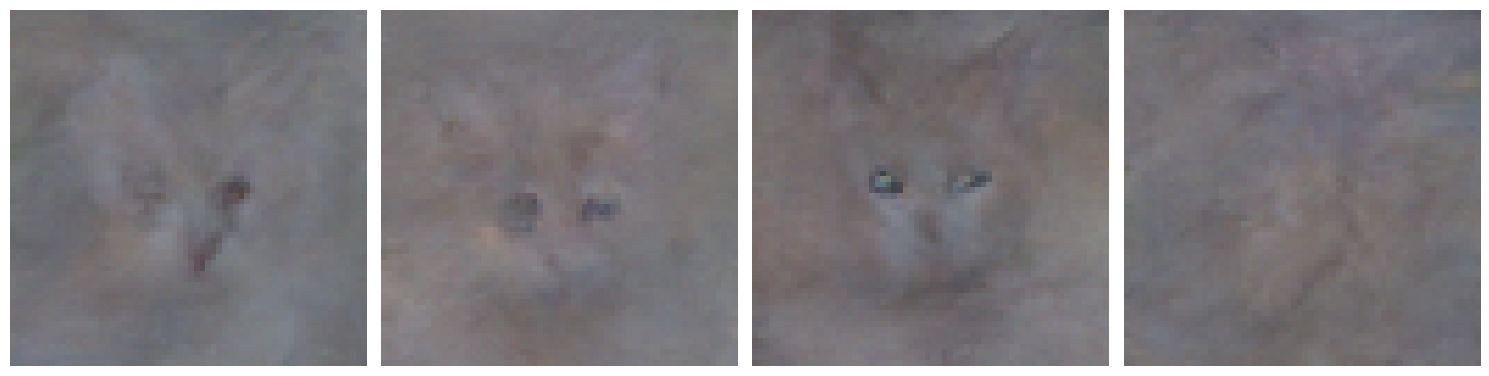

In [25]:
import matplotlib.pyplot as plt

def generate_from_scratch(model, diffusion, class_label=0, clip_embeddings=None, guidance_scale=0.5, n_images=4):
    """
    Generates images from pure noise with classifier-free guidance.
    """
    model.eval()
    with torch.no_grad():
        # 1. Start from Pure Random Noise
        x = torch.randn((n_images, 3, diffusion.img_size, diffusion.img_size)).to(device)
        
        # Get CLIP embedding for target class
        target_clip_emb = clip_embeddings[class_label].unsqueeze(0).expand(n_images, -1).to(device)
        
        # 2. Denoise loop with classifier-free guidance
        for i in reversed(range(1, diffusion.noise_steps)):
            t = torch.ones(n_images).long().to(device) * i
            
            # Predict with conditioning
            predicted_noise_cond = model(x, t, target_clip_emb)
            
            # Predict without conditioning (guidance)
            null_emb = torch.zeros_like(target_clip_emb)
            predicted_noise_uncond = model(x, t, null_emb)
            
            # Combine with guidance
            predicted_noise = predicted_noise_uncond + guidance_scale * (predicted_noise_cond - predicted_noise_uncond)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            x = torch.clamp(x, -1.0, 1.0)
    
    # 3. Un-normalize from [-1, 1] to [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x

# --- RUN DIAGNOSTIC ---
diff_debug = Diffusion(img_size=IMG_SIZE, device=device, schedule="cosine")

# Generate 4 Cats
print("Attempting to generate 4 Cats from scratch...")
gen_imgs = generate_from_scratch(model, diff_debug, class_label=0, clip_embeddings=clip_embeddings, n_images=4)

plt.figure(figsize=(15, 5))
for i in range(len(gen_imgs)):
    plt.subplot(1, 4, i+1)
    
    img = gen_imgs[i].detach().cpu()
    img = img.permute(1, 2, 0)
    
    plt.imshow(img.clamp(0, 1))
    plt.axis('off')
    
plt.tight_layout()
plt.show()
